# Módulo 3: Exceso de Pérdida (Excess of Loss — XL)

## ¿Qué es?

El reasegurador cubre el exceso de cada siniestro individual $Y_j$
que supere el retention limit $M$, hasta un límite $L$.

$$Y_j^{\text{retenido}} = \min(Y_j, M)$$
$$Y_j^{\text{cedido}} = \min\big((Y_j - M)_+,\ L\big)$$

La pérdida agregada retenida es:

$$S^{\text{retenido}} = \sum_{j=1}^{N} \min(Y_j, M)$$

Usamos $M = 100,000$ y $L = 400,000$.

In [14]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.simulation import simulate_aggregate_losses
from src.treaties import apply_excess_of_loss

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


## Simulación con siniestros individuales

Para aplicar el XL necesitamos los siniestros individuales $Y_j$,
no solo la pérdida agregada $S$. Simulamos de nuevo guardando
cada siniestro por separado.

In [15]:
# Parámetros
N_SIM      = 100_000
LAM        = 50.0
ALPHA      = 1.5
XM         = 1_000.0
M          = 100_000.0
L          = 400_000.0
SEED       = 42

rng = np.random.default_rng(SEED)

# Simular frecuencia
N = rng.poisson(lam=LAM, size=N_SIM)

# Simular siniestros individuales y aplicar XL
S_bruto    = np.zeros(N_SIM)
S_retenido = np.zeros(N_SIM)
S_cedido   = np.zeros(N_SIM)

for i, n in enumerate(N):
    if n == 0:
        continue

    # Severidad Pareto
    U = rng.uniform(size=n)
    Y = XM / (U ** (1.0 / ALPHA))

    # Aplicar XL siniestro por siniestro
    resultado = apply_excess_of_loss(Y, M=M, L=L)

    S_bruto[i]    = Y.sum()
    S_retenido[i] = resultado["retained"].sum()
    S_cedido[i]   = resultado["ceded"].sum()

print(f"{'Métrica':<20} {'Bruto':>15} {'Retenido XL':>15}")
print("=" * 52)
print(f"{'Media':<20} {S_bruto.mean():>15,.2f} {S_retenido.mean():>15,.2f}")
print(f"{'Desv. estándar':<20} {S_bruto.std():>15,.2f} {S_retenido.std():>15,.2f}")
print(f"{'VaR 99%':<20} {np.percentile(S_bruto,99):>15,.2f} {np.percentile(S_retenido,99):>15,.2f}")
print(f"{'Máximo':<20} {S_bruto.max():>15,.2f} {S_retenido.max():>15,.2f}")

Métrica                        Bruto     Retenido XL
Media                     149,069.14      139,919.83
Desv. estándar            204,664.09       43,009.30
VaR 99%                   437,966.07      276,153.70
Máximo                 40,184,892.30      467,407.16


## Visualización: Bruto vs Retenido (Excess of Loss)

El XL corta la cola derecha de la distribución.
La forma cambia radicalmente, ya no es cola pesada.

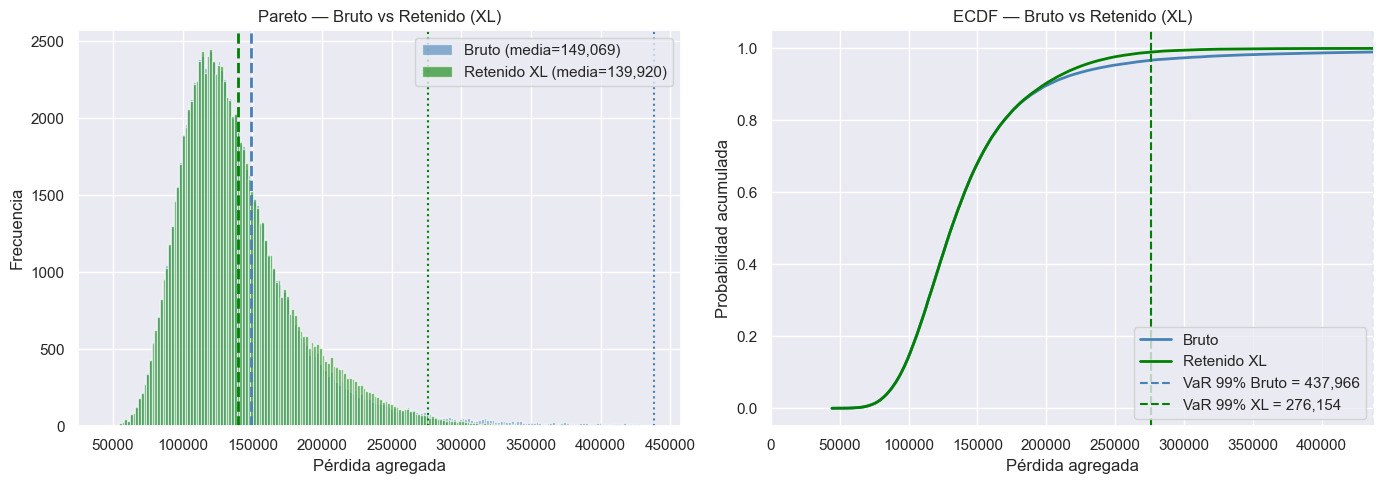

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

p99_bruto    = np.percentile(S_bruto, 99)
p99_retenido = np.percentile(S_retenido, 99)
x_max        = p99_bruto

# --- Gráfica 1: Histograma ---
axes[0].hist(S_bruto[S_bruto <= x_max], bins=200, alpha=0.6,
             color="steelblue", label=f"Bruto (media={S_bruto.mean():,.0f})")
axes[0].hist(S_retenido[S_retenido <= x_max], bins=200, alpha=0.6,
             color="green", label=f"Retenido XL (media={S_retenido.mean():,.0f})")
axes[0].axvline(S_bruto.mean(),    color="steelblue", linewidth=2, linestyle="--")
axes[0].axvline(S_retenido.mean(), color="green",     linewidth=2, linestyle="--")
axes[0].axvline(p99_bruto,         color="steelblue", linewidth=1.5, linestyle=":")
axes[0].axvline(p99_retenido,      color="green",     linewidth=1.5, linestyle=":")
axes[0].set_title("Pareto — Bruto vs Retenido (XL)")
axes[0].set_xlabel("Pérdida agregada")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()

# --- Gráfica 2: ECDF ---
S_sorted   = np.sort(S_bruto)
ret_sorted = np.sort(S_retenido)
prob       = np.arange(1, len(S_sorted) + 1) / len(S_sorted)

axes[1].plot(S_sorted,   prob, color="steelblue", linewidth=2, label="Bruto")
axes[1].plot(ret_sorted, prob, color="green",     linewidth=2, label="Retenido XL")
axes[1].axvline(p99_bruto,    color="steelblue", linewidth=1.5, linestyle="--",
                label=f"VaR 99% Bruto = {p99_bruto:,.0f}")
axes[1].axvline(p99_retenido, color="green",     linewidth=1.5, linestyle="--",
                label=f"VaR 99% XL = {p99_retenido:,.0f}")
axes[1].set_xlim(0, x_max)
axes[1].set_title("ECDF — Bruto vs Retenido (XL)")
axes[1].set_xlabel("Pérdida agregada")
axes[1].set_ylabel("Probabilidad acumulada")
axes[1].legend()

plt.tight_layout()
plt.savefig("../figures/04_excess_of_loss_pareto.png", dpi=150, bbox_inches="tight")
plt.show()

## Resumen de métricas — Excess of Loss

Comparamos las métricas actuariales del portafolio bruto
contra el retenido bajo XL con $M = 100,000$ y $L = 400,000$.

In [ ]:
def resumen_metricas(S, nombre):
    var99  = np.percentile(S, 99)
    cvar99 = S[S > var99].mean()
    media  = S.mean()
    std    = S.std()
    prima  = media + 1.5 * std
    return {
        "Tratado"        : nombre,
        "Media"          : media,
        "Desv. Estándar" : std,
        "VaR 99%"        : var99,
        "CVaR 99%"       : cvar99,
        "Prima Técnica"  : prima,
    }

# Cargar retenido de Quota Share para comparar
df         = pd.read_csv("../data/simulated_losses.csv")
S_pareto   = df["S_pareto"].values
ret_qs     = S_pareto * 0.60

metricas = pd.DataFrame([
    resumen_metricas(S_pareto,    "Bruto"),
    resumen_metricas(ret_qs,      "Quota Share"),
    resumen_metricas(S_retenido,  "Excess of Loss"),
])

metricas.set_index("Tratado", inplace=True)
print(metricas.map(lambda x: f"{x:,.2f}"))

                     Media Desv. Estándar     VaR 99%    CVaR 99%  \
Tratado                                                             
Bruto           149,069.14     204,664.09  437,966.07  943,990.34   
Quota Share      89,441.49     122,798.45  262,779.64  566,394.20   
Excess of Loss  139,919.83      43,009.30  276,153.70  308,078.07   

               Prima Técnica  
Tratado                       
Bruto             456,065.27  
Quota Share       273,639.16  
Excess of Loss    204,433.77  
